# MP5: Training Your Diffusion Model!

## Setup environment

In [13]:
# Import essential modules. Feel free to add whatever you need.
import matplotlib.pyplot as plt
import torch
from torch import optim 
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor
from tqdm.notebook import tqdm # For progress bars

## Visualization helper function

In [3]:
def visualize_images_with_titles(images: torch.Tensor, column_names: list[str]):
    """
    Visualize images as a grid and title the columns with the provided names.

    Args:
        images: (N, C, H, W) tensor of images, where N is (number of rows * number of columns)
        column_names: List of column names for the titles.

    Example usage:
    visualize_images_with_titles(torch.randn(16, 1, 32, 32), ['1', '2', '3', '4'])
    """
    num_images, num_columns = images.shape[0], len(column_names)
    assert num_images % num_columns == 0, 'Number of images must be a multiple of the number of columns.'

    num_rows = num_images // num_columns
    fig, axes = plt.subplots(num_rows, num_columns, figsize=(num_columns * 1, num_rows * 1))

    for i, ax in enumerate(axes.flat):
        img = images[i].permute(1, 2, 0).cpu().detach().numpy()
        ax.imshow(img, cmap='gray')
        ax.axis('off')
        if i < num_columns:
            ax.set_title(column_names[i % num_columns])

    plt.tight_layout()
    plt.show()


# Part 1: Training a Single-step Denoising UNet


## Implementing Simple and Composed Ops

In [10]:

class Conv(nn.Module):
    """
    Conv is a convolutional layer that doesn't change the image resolution, only the channel dimension.
    """
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels

        self.conv = nn.Conv2d(in_channels=in_channels, out_channels=out_channels, kernel_size=1)
        self.bn = nn.BatchNorm2d(num_features=out_channels)
        self.gelu = nn.GELU()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Conv2d(3,1,1) + BN (nn.BatchNorm2d()) + GELU (nn.GELU())
        """
        conv_result = self.conv(x)
        bn_result = self.bn(conv_result)
        gelu_result = self.gelu(bn_result)
        assert gelu_result.shape == (x.shape[0], self.out_channels, x.shape[2], x.shape[3]), \
            f"Expected shape {(x.shape[0], self.out_channels, x.shape[2], x.shape[3])}, but got {gelu_result.shape}"
        return gelu_result


class DownConv(nn.Module):
    """
    DownConv is a convolutional layer that downsamples the tensor by 2.
    D_in, H, W => D_out, H/2, W/2
    """
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels

        self.conv = nn.Conv2d(in_channels=in_channels, out_channels=out_channels, kernel_size=3, stride=2, padding=1)
        self.bn = nn.BatchNorm2d(num_features=out_channels)
        self.gelu = nn.GELU()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Conv2d (3,2,1) + BN + GELU"""
        # Conv2d(3,2,1) + BN (nn.BatchNorm2d()) + GELU (nn.GELU())
        conv_result = self.conv(x)
        bn_result = self.bn(conv_result)
        gelu_result =self.gelu(bn_result)
        assert gelu_result.shape == (x.shape[0], self.out_channels, x.shape[2] // 2, x.shape[3] // 2), \
            f"Expected shape {(x.shape[0], self.out_channels, x.shape[2] // 2, x.shape[3] // 2)}, but got {gelu_result.shape}"
        return gelu_result


class UpConv(nn.Module):
    """
    UpConv is a convolutional layer that upsamples the tensor by 2.
    """
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.conv_transpose = nn.ConvTranspose2d(in_channels=in_channels, out_channels=out_channels, kernel_size=4, stride=2, padding=1)
        self.bn = nn.BatchNorm2d(num_features=out_channels)
        self.gelu = nn.GELU()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """ConTranspose2d (4,2,1) + BN + GELU"""
        # ConvTranspose2d(4,2,1) + BN (nn.BatchNorm2d()) + GELU (nn.GELU())
        conv_result = self.conv_transpose(x)
        bn_result = self.bn(conv_result)
        gelu_result = self.gelu(bn_result)
        assert gelu_result.shape == (x.shape[0], self.out_channels, x.shape[2] * 2, x.shape[3] * 2), \
            f"Expected shape {(x.shape[0], self.out_channels, x.shape[2] * 2, x.shape[3] * 2)}, but got {gelu_result.shape}"
        return gelu_result


class Flatten(nn.Module):
    """
    Flatten is an average pooling layer that flattens a 7x7 tensor into a 1x1 tensor.
    7 is the resulting height and width after the downsampling operations.
    """

    def __init__(self):
        super().__init__()
        self.avg_pool = nn.AvgPool2d(kernel_size=7)
        self.gelu = nn.GELU()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """AvgPool (7) + GELU"""
        # AvgPool(7) + GELU (nn.GELU())
        avg_pool_result = self.avg_pool(x)
        gelu_result = self.gelu(avg_pool_result)
        assert gelu_result.shape == (x.shape[0], x.shape[1], 1, 1), 'GELU output shape is incorrect'
        return gelu_result


class Unflatten(nn.Module):
    """
    Unflatten is a convolutional layer that unflattens/upsamples a 1x1 tensor into a 7x7 tensor.
    """
    def __init__(self, in_channels: int):
        super().__init__()
        self.in_channels = in_channels
        self.conv_transpose = nn.ConvTranspose2d(in_channels=in_channels, out_channels=in_channels, kernel_size=7, stride=1, padding=0)
        self.bn = nn.BatchNorm2d(num_features=in_channels)
        self.gelu = nn.GELU()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """ConvTranspose2d(7,7,0) + BN + GELU"""
        # ConvTranspose2d(7,7,0) + BN (nn.BatchNorm2d()) + GELU (nn.GELU())
        conv_result = self.conv_transpose(x)
        bn_result = self.bn(conv_result)
        gelu_result =self.gelu(bn_result)

        assert gelu_result.shape == (x.shape[0], self.in_channels, 7, 7), \
            f"Expected shape {(x.shape[0], self.in_channels, 7, 7)}, but got {gelu_result.shape}"
        return gelu_result


class ConvBlock(nn.Module):
    """
    similar to Conv but includes an additional Conv. 
    Note that it has the same input and output shape as (1) Conv.
    """
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.conv1 = nn.Conv2d(in_channels=in_channels, out_channels=out_channels, kernel_size=1)
        self.bn1 = nn.BatchNorm2d(num_features=out_channels)
        self.gelu1 = nn.GELU()
        self.conv2 = nn.Conv2d(in_channels=out_channels, out_channels=out_channels, kernel_size=1)
        self.bn2 = nn.BatchNorm2d(num_features=out_channels)
        self.gelu2 = nn.GELU()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Conv2d(3,1,1) + BN (nn.BatchNorm2d()) + GELU (nn.GELU()) + Conv2d(1,1,1) + BN (nn.BatchNorm2d()) + GELU (nn.GELU())
        """
        conv_result = self.conv1(x)
        bn_result = self.bn1(conv_result)
        gelu_result = self.gelu1(bn_result)
        conv_result_2 = self.conv2(gelu_result)
        bn_result_2 = self.bn2(conv_result_2)
        gelu_result_2 = self.gelu2(bn_result_2)

        # Check if the output shape is as expected
        assert gelu_result_2.shape == (x.shape[0], self.out_channels, x.shape[2], x.shape[3]), \
            f"Expected shape {(x.shape[0], self.out_channels, x.shape[2], x.shape[3])}, but got {gelu_result_2.shape}"
        return gelu_result_2


class DownBlock(nn.Module):
    """
    similar to DownConv but includes an additional ConvBlock. 
    Note that it has the same input and output shape as (2) DownConv.
    """
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        
        self.down_conv = DownConv(in_channels, out_channels)
        self.conv_block = ConvBlock(out_channels, out_channels)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """DownConv + ConvBlock"""
        # DownConv + ConvBlock
        downconv_result = self.down_conv(x)
        convblock_result = self.conv_block(downconv_result)

        # Check if the output shape is as expected      
        assert convblock_result.shape == (x.shape[0], self.out_channels, x.shape[2] // 2, x.shape[3] // 2), \
            f"Expected shape {(x.shape[0], self.out_channels, x.shape[2] // 2, x.shape[3] // 2)}, but got {convblock_result.shape}"
        
        return convblock_result


class UpBlock(nn.Module):
    """
    similar to UpConv but includes an additional ConvBlock. 
    Note that it has the same input and output shape as (3) UpConv.
    """
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        
        self.up_conv = UpConv(in_channels, out_channels)
        self.conv_block = ConvBlock(out_channels, out_channels)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """UpConv + ConvBlock"""
        # UpConv + ConvBlock
        upconv_result = self.up_conv(x)
        convblock_result = self.conv_block(upconv_result)

        # Check if the output shape is as expected
        assert convblock_result.shape == (x.shape[0], self.out_channels, x.shape[2] * 2, x.shape[3] * 2), \
            f"Expected shape {(x.shape[0], self.out_channels, x.shape[2] * 2, x.shape[3] * 2)}, but got {convblock_result.shape}"
        return convblock_result

## Implementing Unconditional UNet

In [ ]:
class UnconditionalUNet(nn.Module):
    def __init__(
        self,
        in_channels: int,
        num_hiddens: int,
    ):
        self.in_channels = in_channels
        self.num_hiddens = num_hiddens
        
        super().__init__()

        # Layers in U-Net
        self.first_conv = ConvBlock(self.in_channels, num_hiddens)

        # Downsampling Path
        self.down1 = DownBlock(num_hiddens, num_hiddens)
        self.down2 = DownBlock(num_hiddens, num_hiddens * 2)

        # Flatten and Unflatten (bottom of U-Net)
        self.flatten = Flatten()
        self.unflatten = Unflatten(num_hiddens * 2)

        # Upsampling Path
        # upsample1 is the one that receives the concatenatino of Unflatten and DownBlock
        self.upsample1 = UpBlock(num_hiddens * 4, num_hiddens)
        self.upsample2 = UpBlock(num_hiddens * 2, num_hiddens)

        # Final Convolution Blocks
        self.final_conv1 = ConvBlock(num_hiddens * 2, num_hiddens)
        self.final_conv2 = nn.Conv2d(num_hiddens, self.in_channels, kernel_size=3, stride=1, padding=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        assert x.shape[-2:] == (28, 28), "Expect input shape to be (28, 28)."

        # Encoder?
        c1 = self.first_conv(x)
        d1 = self.down1(c1)
        d2 = self.down2(d1)

        # Bottleneck
        flat = self.flatten(d2)
        b = self.unflatten(flat)

        # Decoder
        cat1 = torch.cat((b, d2), dim=1)
        u1 = self.upsample1(cat1)

        ## Second level
        cat2 = torch.cat((u1, d1), dim=1)
        u2 = self.upsample2(cat2)

        ## Final (top) level
        cat3 = torch.cat((u2, c1), dim=1)
        f1 = self.final_conv1(cat3)

        # Final convolution
        out_res = self.final_conv2(f1)

        assert out_res.shape == x.shape, f"Output shape {out_res.shape} doesn't match input shape {x.shape}"
        
        return out_res

## Visualizing the noising process

In [ ]:
dataset = MNIST(root="data", download=True, transform=ToTensor(), train=True)

train_loader = DataLoader(dataset, batch_size=16, shuffle=True)
# Get a batch of data
for images, labels in train_loader:
    break
# Create an instance of the model
model = UnconditionalUNet(in_channels=1, num_hiddens=16)



# Forward pass
output = model(images)
# Visualize the output
visualize_images_with_titles(output, ['Output 1', 'Output 2', 'Output 3', 'Output 4'])
# Visualize the input
visualize_images_with_titles(images, ['Input 1', 'Input 2', 'Input 3', 'Input 4'])
# Visualize the labels by printing them
print("Labels (4x4 matrix):")
print(labels.reshape(4, 4))


In [ ]:
ITERATIONS = 9
NUM_IMAGES = 5

dataset = MNIST(root="data", download=True, transform=ToTensor(), train=True)
train_loader = DataLoader(dataset, batch_size=16, shuffle=True)

for images, labels in train_loader:
    break
# Create an instance of the model
model = UnconditionalUNet(in_channels=1, num_hiddens=16)

with torch.no_grad():
    # Select the first {NUM_IMAGES} images in the batch
    imgs = images[:NUM_IMAGES]
    progression = [imgs.clone()]

    # Pass the images through the model for {ITERATIONS} iterations
    for i in range(ITERATIONS):
        imgs = model(imgs)
        progression.append(imgs.clone())

# Plot the original images and their progression
num_iters = len(progression)  # 9 iterations (initial + ITERATIONS steps)
num_imgs = progression[0].shape[0]  # NUM_IMAGES images

fig, axes = plt.subplots(num_imgs, num_iters, figsize=(num_iters * 2, num_imgs * 2))
for i in range(num_imgs):
    for j in range(num_iters):
        axes[i, j].imshow(progression[j][i].squeeze().cpu(), cmap="gray")
        axes[i, j].axis("off")
        if i == 0:
            axes[i, j].set_title(f"Iter {j}")
plt.tight_layout()
plt.show()

## Training a Single-Step Unconditional UNet

- Plot the loss curve
- Sample results on the test set

In [ ]:
dataset = MNIST(root='data', download=True, transform=ToTensor(), train=True)
dataloader = DataLoader(dataset, batch_size=256, shuffle=True)


EPOCHS = 5
BATCH_SIZE = 256
LEARNING_RATE = 1e-4
NUM_HIDDENS = 128 # 'D' in the UNet diagram
NOISE_SIGMA = 0.5 # Fixed noise level for this part
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.mps.is_available() else"cpu")
print(f"Using device: {DEVICE}")

In [ ]:
# DataLoaders
train_dataset = MNIST(root='data', download=True, transform=ToTensor(), train=True)
test_dataset = MNIST(root='data', download=True, transform=ToTensor(), train=False)

train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
# We only need a small fixed batch from the test set for visualization

test_subset_indices = range(8) # Let's visualize 20 images
test_subset = Subset(test_dataset, test_subset_indices)
vis_dataloader = DataLoader(test_subset, batch_size=len(test_subset_indices)) # Load all images at once


# Initialization of the model + move to device
model = UnconditionalUNet(in_channels=1, num_hiddens=NUM_HIDDENS).to(DEVICE)

criterion = nn.MSELoss() # L2 Loss
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# --- 3. Visualization Prep ---\
# Get the fixed batch of test images
fixed_vis_images, _ = next(iter(vis_dataloader))
fixed_vis_images = fixed_vis_images.to(DEVICE)
# Generate fixed noise for these images ONCE
torch.manual_seed(42) # for reproducible noise
fixed_noise = torch.randn_like(fixed_vis_images).to(device=DEVICE) * NOISE_SIGMA

# Create the fixed noisy versions (clamp for visualization only)
fixed_noisy_vis_images = torch.clamp(fixed_vis_images + fixed_noise, 0, 1)


In [ ]:
# --- 4. Training Loop ---\
train_losses = []
step_count = 0

for epoch in range(EPOCHS):
    model.train() # Set model to training mode
    epoch_loss = 0.0
    progress_bar = tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{EPOCHS}", leave=False)

    for batch_idx, (clean_images, _) in enumerate(progress_bar):
        clean_images = clean_images.to(DEVICE) # (N, 1, 28, 28)

        # --- Generate Noisy Input for this batch ---\
        # Generate NEW noise for every batch
        noise = torch.randn_like(clean_images) * NOISE_SIGMA
        noisy_input = clean_images + noise
        # Note: We don't clamp the input to the model, only the visualized noise
        noisy_input = noisy_input.to(DEVICE) # (N, 1, 28, 28)


        denoised_output = model(noisy_input)

        # Loss is between model output and the ORIGINAL CLEAN image
        loss = criterion(denoised_output, clean_images)

        # --- Backward Pass & Optimization ---\
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # --- Logging ---\
        current_loss = loss.item()
        epoch_loss += current_loss
        train_losses.append(current_loss)
        step_count += 1
        progress_bar.set_postfix(loss=f"{current_loss:.4f}")

    avg_epoch_loss = epoch_loss / len(train_dataloader)
    print(f"Epoch {epoch+1}/{EPOCHS} - Average Training Loss: {avg_epoch_loss:.4f}")

    # Visualization for epoch 1 and 5
    if (epoch + 1) == 1 or (epoch + 1) == EPOCHS:
        print(f"\n--- Visualizing after Epoch {epoch+1} ---")
        model.eval() 
        with torch.no_grad(): 
            denoised_test_output = model(fixed_vis_images + fixed_noise)

        vis_clean = fixed_vis_images.cpu()
        vis_noisy = fixed_noisy_vis_images.cpu()
        vis_denoised = torch.clamp(denoised_test_output.cpu(), 0, 1)

        num_vis = len(vis_clean)
        images_to_show = torch.stack([\
            vis_clean.squeeze(1),
            vis_noisy.squeeze(1),
            vis_denoised.squeeze(1)
        ]).permute(1, 0, 2, 3).reshape(num_vis * 3, 1, 28, 28) # Reshape for grid

        visualize_images_with_titles(
            images_to_show,
            column_names=['Input', f'Noisy (σ={NOISE_SIGMA})', 'Denoised']
        )
        print("-" * 20)



plt.figure(figsize=(10, 5))
plt.plot(range(step_count), train_losses)
plt.xlabel("Training Step")
plt.ylabel("MSE Loss")
plt.title("Training Loss Curve (Single-Step Denoising)")
plt.yscale('log') # Often helpful to see loss changes
plt.grid(True)
plt.show()

print("Training finished.")


In [ ]:
PATH = "unconditional_unet.pth"
torch.save(model.state_dict(), PATH)
print(f"Model saved as {PATH}")

## Out-of-Distribution Testing

In [ ]:
PATH = "unconditional_unet.pth"
model = UnconditionalUNet(in_channels=1, num_hiddens=NUM_HIDDENS).to(DEVICE)
model.load_state_dict(torch.load(PATH, map_location=DEVICE))
model.eval()
print("Model loaded from", PATH)

In [ ]:
test_images = next(iter(vis_dataloader))[0].to(DEVICE)
sigmas = [0.0, 0.2, 0.4, 0.5, 0.6, 0.8, 1.0] 
# Select the first image from the fixed batch of test images
img = test_images[0:1]

noisy_images_list = []
denoised_images_list = []

model.eval()
with torch.no_grad():
    for sigma in sigmas:
        noise = sigma * torch.randn_like(img)
        noisy = img + noise
        denoised = model(noisy)
        noisy_images_list.append(noisy.cpu())
        denoised_images_list.append(denoised.cpu())

# Create a grid with 2 rows: first row for noisy, second row for denoised images
fig, axes = plt.subplots(2, len(sigmas), figsize=(len(sigmas) * 2, 4))

for i, sigma in enumerate(sigmas):
    # Top row: noisy image
    ax = axes[0, i]
    ax.imshow(noisy_images_list[i].squeeze(), cmap="gray")
    ax.axis("off")
    ax.set_title(f"σ={sigma}", fontsize=10)

    # Bottom row: denoised image
    ax = axes[1, i]
    ax.imshow(denoised_images_list[i].squeeze(), cmap="gray")
    ax.axis("off")
    if i == 0:
        ax.set_ylabel("Denoised", fontsize=10)

plt.tight_layout()
plt.show()


# Part 2: Training a Diffusion Model

## Implementing a Time-conditioned UNet

In [4]:
class FCBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        
        # Definitions for layer
        self.fc = nn.Linear(in_channels, out_channels)
        self.gelu = nn.GELU()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.fc(x)
        x = self.gelu(x)
        return x



class TimeConditionalUNet(nn.Module):
    def __init__(
        self,
        in_channels: int,
        num_classes: int,
        num_hiddens: int,
    ):
        super().__init__()
        self.in_channels = in_channels
        self.num_classes = num_classes
        self.num_hiddens = num_hiddens

        # Time embedding
        time_embed_dim = num_hiddens * 4
        self.time_embed = nn.Sequential(
            FCBlock(1, time_embed_dim),
            FCBlock(time_embed_dim, time_embed_dim)
        )

        # Projection layers for time embedding
        self.time_proj_1 = nn.Linear(time_embed_dim, num_hiddens)
        self.time_proj_2 = nn.Linear(time_embed_dim, num_hiddens)
        self.time_proj_3 = nn.Linear(time_embed_dim, num_hiddens * 2)

        # Encoder path
        self.first_conv = ConvBlock(in_channels, num_hiddens)
        self.down1 = DownBlock(num_hiddens, num_hiddens)
        self.down2 = DownBlock(num_hiddens, num_hiddens * 2)

        # Bottleneck
        self.flatten = Flatten()
        self.unflatten = Unflatten(num_hiddens * 2)

        # Decoder path
        self.upsample1 = UpBlock(num_hiddens * 4, num_hiddens)
        self.upsample2 = UpBlock(num_hiddens * 2, num_hiddens)

        # Final layers
        self.final_conv1 = ConvBlock(num_hiddens * 2, num_hiddens)
        self.final_conv2 = nn.Conv2d(num_hiddens, in_channels, kernel_size=3, padding=1)

    def forward(self, x: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: (N, C, H, W) input tensor
            t: (N,) normalized time tensor
        """
        assert x.shape[-2:] == (28, 28), "Expected input shape to be (28, 28)"

        # Time embedding
        t = t.unsqueeze(-1).float()  # (N, 1)
        t_emb = self.time_embed(t)   # (N, time_embed_dim)

        # Project time embeddings for different layers
        t1 = self.time_proj_1(t_emb).unsqueeze(-1).unsqueeze(-1)  # (N, num_hiddens, 1, 1)
        t2 = self.time_proj_2(t_emb).unsqueeze(-1).unsqueeze(-1)  # (N, num_hiddens, 1, 1)
        t3 = self.time_proj_3(t_emb).unsqueeze(-1).unsqueeze(-1)  # (N, num_hiddens * 2, 1, 1)

        # Encoder
        x1 = self.first_conv(x)
        x1 = x1 + t1.expand_as(x1)

        x2 = self.down1(x1)
        x2 = x2 + t2.expand_as(x2)

        x3 = self.down2(x2)
        x3 = x3 + t3.expand_as(x3)

        # Bottleneck
        x_flat = self.flatten(x3)
        x_bottle = self.unflatten(x_flat)

        # Decoder with skip connections
        x = torch.cat([x_bottle, x3], dim=1)
        x = self.upsample1(x)

        x = torch.cat([x, x2], dim=1)
        x = self.upsample2(x)

        x = torch.cat([x, x1], dim=1)
        x = self.final_conv1(x)
        x = self.final_conv2(x)

        return x


## Implementing DDPM Forward and Inverse Process for Time-conditioned Denoising

In [5]:
def ddpm_schedule(beta1: float, beta2: float, num_ts: int) -> dict:
    """Constants for DDPM training and sampling.

    Arguments:
        beta1: float, starting beta value.
        beta2: float, ending beta value.
        num_ts: int, number of timesteps.

    Returns:
        dict with keys:
            betas: linear schedule of betas from beta1 to beta2.
            alphas: 1 - betas.
            alpha_bars: cumulative product of alphas.
    """
    assert beta1 < beta2 < 1.0, "Expect beta1 < beta2 < 1.0."
    
    # Linear schedule of beta values
    betas = torch.linspace(beta1, beta2, num_ts)
    
    # Calculate alphas
    alphas = 1 - betas
    
    # Calculate cumulative product of alphas
    alpha_bars = torch.cumprod(alphas, dim=0)
    
    return {
        'betas': betas,
        'alphas': alphas,
        'alpha_bars': alpha_bars
    }

In [6]:
def ddpm_forward(
    unet: TimeConditionalUNet,
    ddpm_schedule: dict,
    x_0: torch.Tensor,
    num_ts: int,
) -> torch.Tensor:
    """Algorithm 1 of the DDPM paper.

    Args:
        unet: TimeConditionalUNet
        ddpm_schedule: dict
        x_0: (N, C, H, W) input tensor.
        num_ts: int, number of timesteps.
    Returns:
        (,) diffusion loss.
    """
    unet.train()
    
    # Sample timestep uniformly
    t = torch.randint(0, num_ts, (x_0.shape[0],), device=x_0.device)
    
    # Get noise
    epsilon = torch.randn_like(x_0)
    
    # Get alpha_bar for the sampled timestep
    alpha_bar = ddpm_schedule['alpha_bars'][t].view(-1, 1, 1, 1)
    
    # Create noisy sample
    x_t = torch.sqrt(alpha_bar) * x_0 + torch.sqrt(1 - alpha_bar) * epsilon
    
    # Predict noise
    epsilon_theta = unet(x_t, t / num_ts)
    
    # Calculate loss
    loss = F.mse_loss(epsilon_theta, epsilon)
    
    return loss

In [7]:
@torch.inference_mode()
def ddpm_sample(
    unet: TimeConditionalUNet,
    ddpm_schedule: dict,
    img_wh: tuple[int, int],
    num_ts: int,
    seed: int = 42,
) -> torch.Tensor:
    """Algorithm 2 of the DDPM paper with classifier-free guidance.

    Args:
        unet: TimeConditionalUNet
        ddpm_schedule: dict
        img_wh: (H, W) output image width and height.
        num_ts: int, number of timesteps.
        seed: int, random seed.

    Returns:
        (N, C, H, W) final sample.
    """
    unet.eval()
    
    torch.manual_seed(seed)
    
    # Start from random noise
    x_t = torch.randn(1, unet.in_channels, *img_wh, device=next(unet.parameters()).device)
    
    for t in reversed(range(num_ts)):
        t_tensor = torch.tensor([t], device=x_t.device)
        epsilon_theta = unet(x_t, t_tensor / num_ts)
        
        alpha = ddpm_schedule['alphas'][t]
        alpha_bar = ddpm_schedule['alpha_bars'][t]
        beta = ddpm_schedule['betas'][t]
        
        # Add noise if t > 0
        if t > 0:
            noise = torch.randn_like(x_t)
        else:
            noise = 0
            
        # Denoising step
        x_t = (1 / torch.sqrt(alpha)) * (
            x_t - (beta / torch.sqrt(1 - alpha_bar)) * epsilon_theta
        ) + torch.sqrt(beta) * noise
    
    return x_t

In [8]:
class DDPM(nn.Module):
    def __init__(
        self,
        unet: TimeConditionalUNet,
        betas: tuple[float, float] = (1e-4, 0.02),
        num_ts: int = 300,
        p_uncond: float = 0.1,
    ):
        super().__init__()
        self.unet = unet
        self.num_ts = num_ts
        self.p_uncond = p_uncond

        self.ddpm_schedule = nn.ParameterDict(ddpm_schedule(betas[0], betas[1], num_ts))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: (N, C, H, W) input tensor.

        Returns:
            (,) diffusion loss.
        """
        return ddpm_forward(
            self.unet, self.ddpm_schedule, x, self.num_ts
        )

    @torch.inference_mode()
    def sample(
        self,
        img_wh: tuple[int, int],
        seed: int = 0,
    ):
        return ddpm_sample(
            self.unet, self.ddpm_schedule, img_wh, self.num_ts, seed
        )

## Training the Time-conditioned UNet

- Plot the loss curve
- Sample results on the test set

In [15]:
# Set up for training
# dataset = MNIST(root='data', download=True, transform=ToTensor(), train=True)
# dataloader = DataLoader(dataset, batch_size=128, shuffle=True)

# Setup constants and model
EPOCHS = 20
BATCH_SIZE = 32
LEARNING_RATE = 1e-4
NUM_HIDDENS = 32
NUM_TIMESTEPS = 100
BETA1, BETA2 = 1e-4, 0.02
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")

# Initialize model and optimizer
model = TimeConditionalUNet(
    in_channels=1,
    num_classes=10,
    num_hiddens=NUM_HIDDENS
).to(DEVICE)

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Create DDPM schedule
ddpm_sched = ddpm_schedule(BETA1, BETA2, NUM_TIMESTEPS)
for k, v in ddpm_sched.items():
    ddpm_sched[k] = v.to(DEVICE)

# Setup data
train_dataset = MNIST(root='data', train=True, transform=ToTensor(), download=True)
test_dataset = MNIST(root='data', train=False, transform=ToTensor(), download=True)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


Training on mps


Training:   0%|          | 0/1875 [00:00<?, ?it/s]

Epoch 1/20 - Average Loss: 0.1395


Training:   0%|          | 0/1875 [00:00<?, ?it/s]

Epoch 2/20 - Average Loss: 0.0719


...

Epoch 8/20 - Average Loss: 0.0530


Training:   0%|          | 0/1875 [00:00<?, ?it/s]

Epoch 9/20 - Average Loss: 0.0522


Training:   0%|          | 0/1875 [00:00<?, ?it/s]

Epoch 10/20 - Average Loss: 0.0513

Generating samples after epoch 10


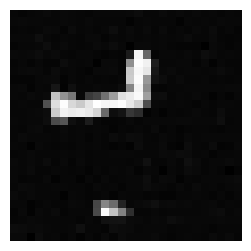

Training:   0%|          | 0/1875 [00:00<?, ?it/s]

Epoch 11/20 - Average Loss: 0.0509


Training:   0%|          | 0/1875 [00:00<?, ?it/s]

Epoch 12/20 - Average Loss: 0.0502


Training:   0%|          | 0/1875 [00:00<?, ?it/s]

...

Epoch 18/20 - Average Loss: 0.0485


Training:   0%|          | 0/1875 [00:00<?, ?it/s]

Epoch 19/20 - Average Loss: 0.0480


Training:   0%|          | 0/1875 [00:00<?, ?it/s]

Epoch 20/20 - Average Loss: 0.0477

Generating samples after epoch 20


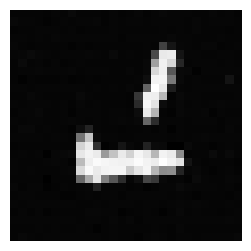

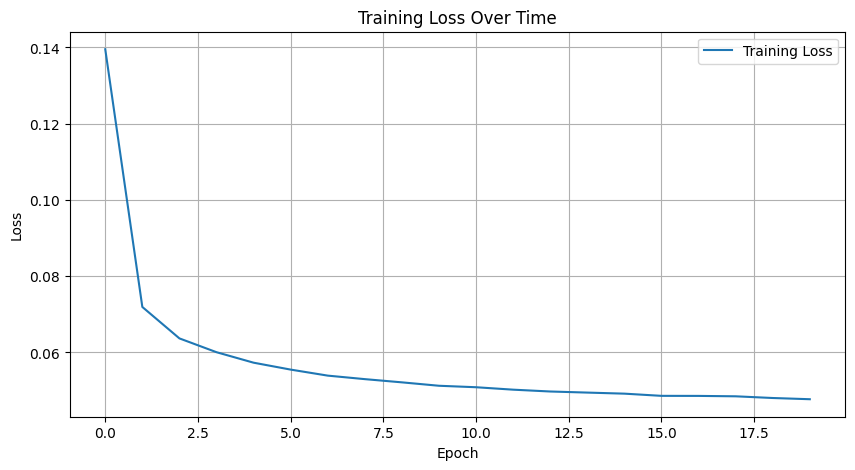

In [16]:
# Training loop
def train_epoch(model, loader, optimizer, ddpm_sched, num_ts):
    model.train()
    total_loss = 0
    progress_bar = tqdm(loader, desc='Training')
    
    for batch_idx, (images, _) in enumerate(progress_bar):
        images = images.to(DEVICE)
        
        optimizer.zero_grad()
        
        # Forward pass
        loss = ddpm_forward(model, ddpm_sched, images, num_ts)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Update progress bar
        total_loss += loss.item()

        if (batch_idx + 1) % 100 == 0:
            avg_loss = total_loss / (batch_idx + 1)
            progress_bar.set_postfix({'Loss': f'{avg_loss:.4f}'})
    
    return total_loss / len(loader)

# Lists to store metrics
train_losses = []

# Training loop with visualization
print(f"Training on {DEVICE}")

for epoch in range(EPOCHS):
    # Train for one epoch
    avg_loss = train_epoch(model, train_loader, optimizer, ddpm_sched, NUM_TIMESTEPS)
    train_losses.append(avg_loss)
    
    # Print progress
    print(f"Epoch {epoch+1}/{EPOCHS} - Average Loss: {avg_loss:.4f}")
    
    # Generate samples every 10 epochs
    if (epoch + 1) % 10 == 0:
        print(f"\nGenerating samples after epoch {epoch+1}")
        model.eval()
        with torch.no_grad():
            # Generate samples
            samples = ddpm_sample(
                model,
                ddpm_sched,
                img_wh=(28, 28),
                num_ts=NUM_TIMESTEPS,
                seed=epoch
            )
            
            # Visualize samples
            plt.figure(figsize=(10, 10))
            for i in range(min(16, samples.shape[0])):
                plt.subplot(4, 4, i+1)
                plt.imshow(samples[i, 0].cpu(), cmap='gray')
                plt.axis('off')
            plt.tight_layout()
            plt.show()

# Plot final loss curve
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Over Time')
plt.legend()
plt.grid(True)
plt.show()


Generating final samples


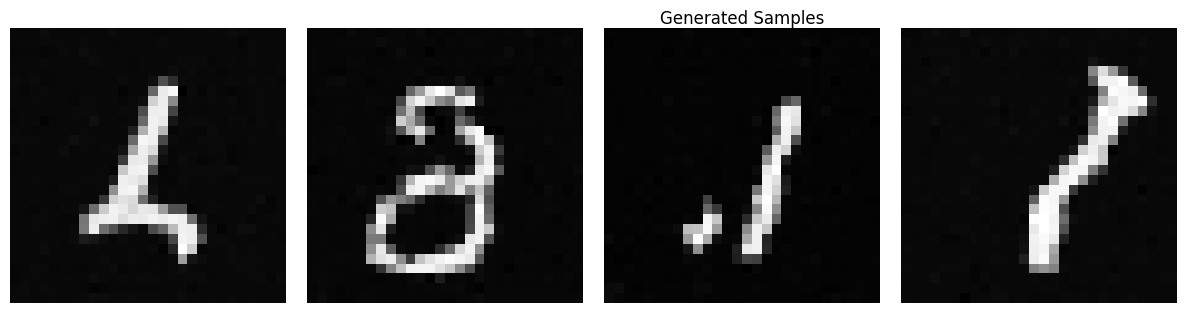

Model saved as time_conditional_unet.pth


In [17]:
# Generate final test samples
print("\nGenerating final samples")
model.eval()
with torch.no_grad():
    # Generate multiple samples
    samples = []
    for i in range(4):  # Generate 4 batches of samples
        sample = ddpm_sample(
            model,
            ddpm_sched,
            img_wh=(28, 28),
            num_ts=NUM_TIMESTEPS,
            seed=i
        )
        samples.append(sample)
    samples = torch.cat(samples, dim=0)
    
    # Create a grid of samples
    plt.figure(figsize=(15, 15))
    for i in range(min(25, samples.shape[0])):
        plt.subplot(5, 5, i+1)
        plt.imshow(samples[i, 0].cpu(), cmap='gray')
        plt.axis('off')
    plt.suptitle('Generated Samples')
    plt.tight_layout()
    plt.show()

# Save the model
torch.save(model.state_dict(), 'time_conditional_unet.pth')
print("Model saved as time_conditional_unet.pth")


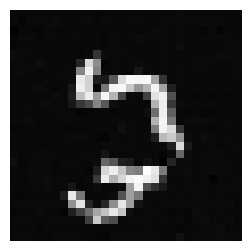

In [24]:
import random
# Load the saved model
model = TimeConditionalUNet(in_channels=1, num_classes=10, num_hiddens=NUM_HIDDENS).to(DEVICE)
model.load_state_dict(torch.load('time_conditional_unet.pth'))

# Generate new samples
with torch.no_grad():
    samples = ddpm_sample(
        model,
        ddpm_sched,
        img_wh=(28, 28),
        num_ts=NUM_TIMESTEPS,
        seed=random.randint(0, 1000)  # Random seed for reproducibility
    )
    
    # Visualize
    plt.figure(figsize=(10, 10))
    for i in range(min(16, samples.shape[0])):
        plt.subplot(4, 4, i+1)
        plt.imshow(samples[i, 0].cpu(), cmap='gray')
        plt.axis('off')
    plt.tight_layout()
    plt.show()


### Implementing class-conditioned UNet

In [50]:
class ClassConditionalUNet(nn.Module):
    def __init__(
        self,
        in_channels: int,
        num_classes: int,
        num_hiddens: int,
    ):
        super().__init__()
        self.in_channels = in_channels
        self.num_classes = num_classes
        self.num_hiddens = num_hiddens

        # Time embedding
        time_embed_dim = num_hiddens * 4
        self.time_embed = nn.Sequential(
            FCBlock(1, time_embed_dim),
            FCBlock(time_embed_dim, time_embed_dim)
        )

        # Class embedding
        self.class_embed = nn.Embedding(num_classes, time_embed_dim)
        
        # Combined embedding projection layers
        self.combined_proj_1 = nn.Linear(time_embed_dim * 2, num_hiddens)
        self.combined_proj_2 = nn.Linear(time_embed_dim * 2, num_hiddens)
        self.combined_proj_3 = nn.Linear(time_embed_dim * 2, num_hiddens * 2)

        # Encoder path
        self.first_conv = ConvBlock(in_channels, num_hiddens)
        self.down1 = DownBlock(num_hiddens, num_hiddens)
        self.down2 = DownBlock(num_hiddens, num_hiddens * 2)

        # Bottleneck
        self.flatten = Flatten()
        self.unflatten = Unflatten(num_hiddens * 2)

        # Decoder path
        self.upsample1 = UpBlock(num_hiddens * 4, num_hiddens)
        self.upsample2 = UpBlock(num_hiddens * 2, num_hiddens)

        # Final layers
        self.final_conv1 = ConvBlock(num_hiddens * 2, num_hiddens)
        self.final_conv2 = nn.Conv2d(num_hiddens, in_channels, kernel_size=3, padding=1)

    def forward(
        self,
        x: torch.Tensor,
        c: torch.Tensor,
        t: torch.Tensor,
        mask: torch.Tensor | None = None,
    ) -> torch.Tensor:
        """
        Args:
            x: (N, C, H, W) input tensor.
            c: (N,) int64 condition tensor.
            t: (N,) normalized time tensor.
            mask: (N,) mask tensor. If not None, mask out condition when mask == 0.
        Returns:
            (N, C, H, W) output tensor.
        """
        # assert x.shape[-2:] == (28, 28), "Expect input shape to be (28, 28)."
        
        # Time embedding
        t = t.unsqueeze(-1).float()  # (N, 1)
        t_emb = self.time_embed(t)   # (N, time_embed_dim)

        # Class embedding
        c_emb = self.class_embed(c)  # (N, time_embed_dim)

        # Apply masking if provided
        if mask is not None:
            mask = mask.unsqueeze(-1)  # (N, 1)
            c_emb = c_emb * mask  # Zero out embeddings for masked indices

        # Combine time and class embeddings
        combined_emb = torch.cat([t_emb, c_emb], dim=1)  # (N, time_embed_dim * 2)

        # Project combined embeddings for different layers
        emb1 = self.combined_proj_1(combined_emb).unsqueeze(-1).unsqueeze(-1)  # (N, num_hiddens, 1, 1)
        emb2 = self.combined_proj_2(combined_emb).unsqueeze(-1).unsqueeze(-1)  # (N, num_hiddens, 1, 1)
        emb3 = self.combined_proj_3(combined_emb).unsqueeze(-1).unsqueeze(-1)  # (N, num_hiddens * 2, 1, 1)

        # Encoder
        x1 = self.first_conv(x)
        x1 = x1 + emb1.expand_as(x1)

        x2 = self.down1(x1)
        x2 = x2 + emb2.expand_as(x2)

        x3 = self.down2(x2)
        x3 = x3 + emb3.expand_as(x3)

        # Bottleneck
        x_flat = self.flatten(x3)
        x_bottle = self.unflatten(x_flat)

        # Decoder with skip connections
        x = torch.cat([x_bottle, x3], dim=1)
        x = self.upsample1(x)

        x = torch.cat([x, x2], dim=1)
        x = self.upsample2(x)

        x = torch.cat([x, x1], dim=1)
        x = self.final_conv1(x)
        x = self.final_conv2(x)

        return x


In [51]:
def ddpm_forward(
    unet: ClassConditionalUNet,
    ddpm_schedule: dict,
    x_0: torch.Tensor,
    c: torch.Tensor,
    p_uncond: float,
    num_ts: int,
) -> torch.Tensor:
    """Algorithm 1 of the DDPM paper with classifier-free guidance."""
    unet.train()
    
    # Sample timestep uniformly
    t = torch.randint(0, num_ts, (x_0.shape[0],), device=x_0.device)
    
    epsilon = torch.randn_like(x_0)
    alpha_bar = ddpm_schedule['alpha_bars'][t].view(-1, 1, 1, 1)
    x_t = torch.sqrt(alpha_bar) * x_0 + torch.sqrt(1 - alpha_bar) * epsilon
    
    mask = torch.rand(x_0.shape[0], device=x_0.device) > p_uncond
    epsilon_theta = unet(x_t, c, t / num_ts, mask)
    loss = F.mse_loss(epsilon_theta, epsilon)
    
    return loss

@torch.inference_mode()
def ddpm_sample(
    unet: ClassConditionalUNet,
    ddpm_schedule: dict,
    c: torch.Tensor,
    img_wh: tuple[int, int],
    num_ts: int,
    guidance_scale: float = 5.0,
    seed: int = 0,
) -> torch.Tensor:
    """Algorithm 2 of the DDPM paper with classifier-free guidance."""
    unet.eval()
    
    torch.manual_seed(seed)
    
    x_t = torch.randn(c.shape[0], unet.in_channels, *img_wh, device=c.device)
    
    for t in reversed(range(num_ts)):
        t_tensor = torch.tensor([t] * c.shape[0], device=c.device)
        t_scaled = t_tensor / num_ts
        
        eps_cond = unet(x_t, c, t_scaled, mask=torch.ones_like(c, dtype=torch.bool))
        eps_uncond = unet(x_t, c, t_scaled, mask=torch.zeros_like(c, dtype=torch.bool))
        
        epsilon_theta = eps_uncond + guidance_scale * (eps_cond - eps_uncond)
        
        alpha = ddpm_schedule['alphas'][t]
        alpha_bar = ddpm_schedule['alpha_bars'][t]
        beta = ddpm_schedule['betas'][t]
        
        # Add noise if t > 0
        if t > 0:
            noise = torch.randn_like(x_t)
        else:
            noise = 0
            
        # Denoising step
        x_t = (1 / torch.sqrt(alpha)) * (
            x_t - (beta / torch.sqrt(1 - alpha_bar)) * epsilon_theta
        ) + torch.sqrt(beta) * noise
    
    return x_t


In [52]:
@torch.inference_mode()
def ddpm_sample(
    unet: ClassConditionalUNet,
    ddpm_schedule: dict,
    c: torch.Tensor,
    img_wh: tuple[int, int],
    num_ts: int,
    guidance_scale: float = 5.0,
    seed: int = 0,
) -> torch.Tensor:
    """Algorithm 2 of the DDPM paper with classifier-free guidance."""
    unet.eval()
    
    torch.manual_seed(seed)
    
    x_t = torch.randn(c.shape[0], unet.in_channels, *img_wh, device=c.device)
    
    for t in reversed(range(num_ts)):
        t_tensor = torch.tensor([t] * c.shape[0], device=c.device)
        t_scaled = t_tensor / num_ts
        
        eps_cond = unet(x_t, c, t_scaled, mask=torch.ones_like(c, dtype=torch.bool))
        eps_uncond = unet(x_t, c, t_scaled, mask=torch.zeros_like(c, dtype=torch.bool))
        
        epsilon_theta = eps_uncond + guidance_scale * (eps_cond - eps_uncond)
        
        alpha = ddpm_schedule['alphas'][t]
        alpha_bar = ddpm_schedule['alpha_bars'][t]
        beta = ddpm_schedule['betas'][t]
        
        if t > 0:
            noise = torch.randn_like(x_t)
        else:
            noise = 0
            
        # Denoising step
        x_t = (1 / torch.sqrt(alpha)) * (
            x_t - (beta / torch.sqrt(1 - alpha_bar)) * epsilon_theta
        ) + torch.sqrt(beta) * noise
    
    return x_t

In [53]:
class DDPM(nn.Module):
    def __init__(
        self,
        unet: ClassConditionalUNet,
        betas: tuple[float, float] = (1e-4, 0.02),
        num_ts: int = 300,
        p_uncond: float = 0.1,
    ):
        super().__init__()
        self.unet = unet
        self.betas = betas
        self.num_ts = num_ts
        self.p_uncond = p_uncond
        self.ddpm_schedule = nn.ParameterDict(ddpm_schedule(betas[0], betas[1], num_ts))

    def forward(self, x: torch.Tensor, c: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: (N, C, H, W) input tensor.
            c: (N,) int64 condition tensor.

        Returns:
            (,) diffusion loss.
        """
        return ddpm_forward(
            self.unet, self.ddpm_schedule, x, c, self.p_uncond, self.num_ts
        )

    @torch.inference_mode()
    def sample(
        self,
        c: torch.Tensor,
        img_wh: tuple[int, int],
        guidance_scale: float = 5.0,
        seed: int = 0,
    ):
        return ddpm_sample(
            self.unet, self.ddpm_schedule, c, img_wh, self.num_ts, guidance_scale, seed
        )

## Training the Class-conditioned UNet

- Plot the loss curve
- Sample results on the test set

In [54]:
# Setup constants and model
EPOCHS = 20
BATCH_SIZE = 128
LEARNING_RATE = 2e-4
NUM_HIDDENS = 64
NUM_TIMESTEPS = 1000
BETA1, BETA2 = 1e-4, 0.02
P_UNCOND = 0.1  # Probability of unconditional training
GUIDANCE_SCALE = 3.0  # For sampling
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")

# Initialize model and optimizer
model = ClassConditionalUNet(
    in_channels=1,
    num_classes=10,  # For MNIST digits 0-9
    num_hiddens=NUM_HIDDENS
).to(DEVICE)

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Create DDPM schedule
ddpm_sched = ddpm_schedule(BETA1, BETA2, NUM_TIMESTEPS)
for k, v in ddpm_sched.items():
    ddpm_sched[k] = v.to(DEVICE)

# Setup data
train_dataset = MNIST(root='data', train=True, transform=ToTensor(), download=True)
test_dataset = MNIST(root='data', train=False, transform=ToTensor(), download=True)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


In [55]:
# Training loop
def train_epoch(model, loader, optimizer, ddpm_sched, num_ts, p_uncond):
    model.train()
    total_loss = 0
    progress_bar = tqdm(loader, desc='Training')
    
    for batch_idx, (images, labels) in enumerate(progress_bar):
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        
        optimizer.zero_grad()
        
        # Forward pass
        loss = ddpm_forward(model, ddpm_sched, images, labels, p_uncond, num_ts)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Update progress bar
        total_loss += loss.item()
        avg_loss = total_loss / (batch_idx + 1)
        progress_bar.set_postfix({'Loss': f'{avg_loss:.4f}'})
    
    return total_loss / len(loader)


Training on mps


Training:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 1/20 - Average Loss: 0.0947


Training:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 2/20 - Average Loss: 0.0291


...

Epoch 8/20 - Average Loss: 0.0192


Training:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 9/20 - Average Loss: 0.0190


Training:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 10/20 - Average Loss: 0.0184

Generating samples after epoch 10


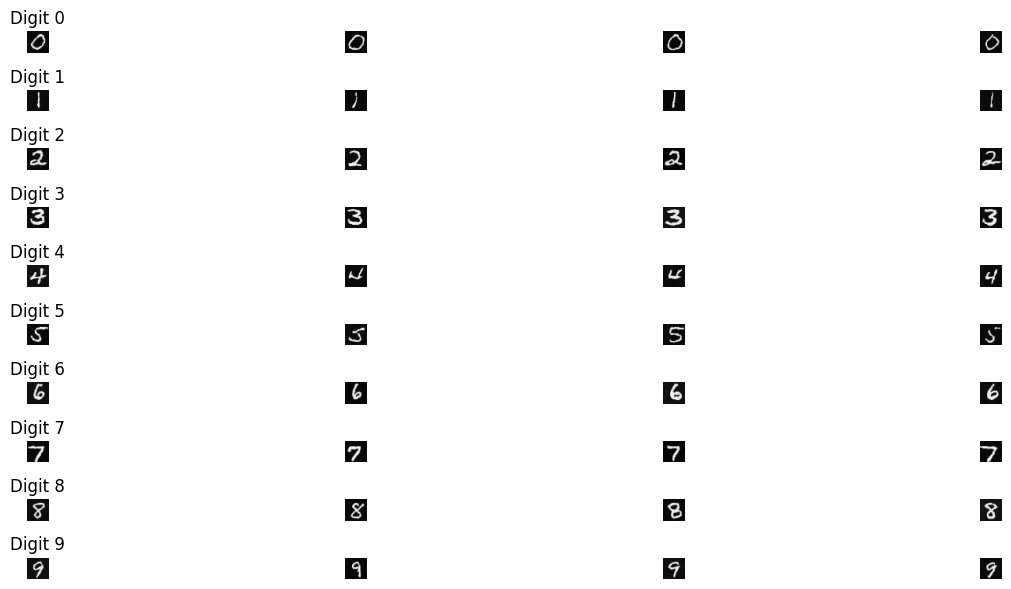

Training:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 11/20 - Average Loss: 0.0184


Training:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 12/20 - Average Loss: 0.0182


Training:   0%|          | 0/469 [00:00<?, ?it/s]

...

Epoch 18/20 - Average Loss: 0.0174


Training:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 19/20 - Average Loss: 0.0174


Training:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 20/20 - Average Loss: 0.0168

Generating samples after epoch 20


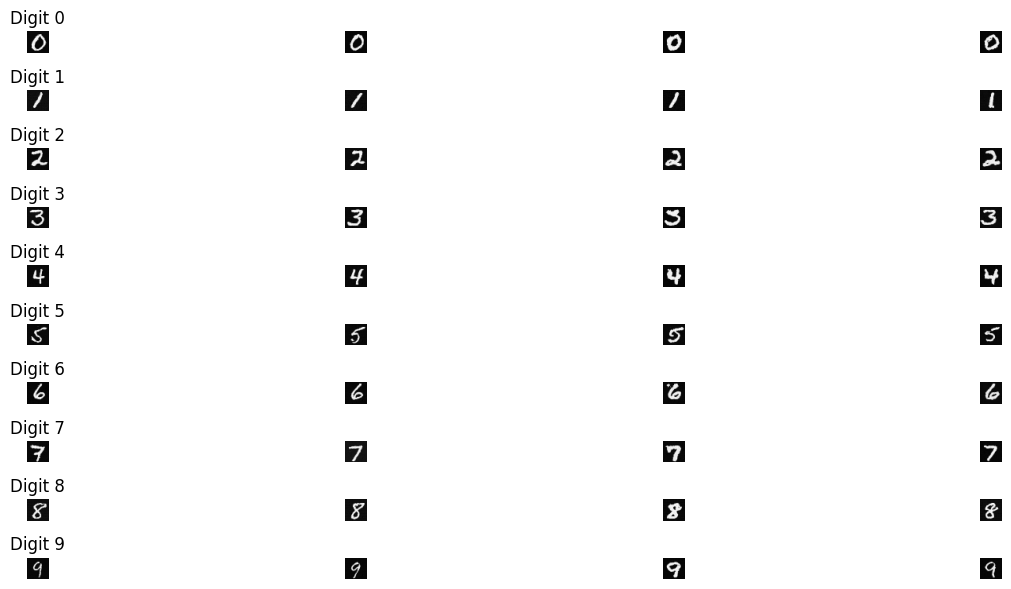

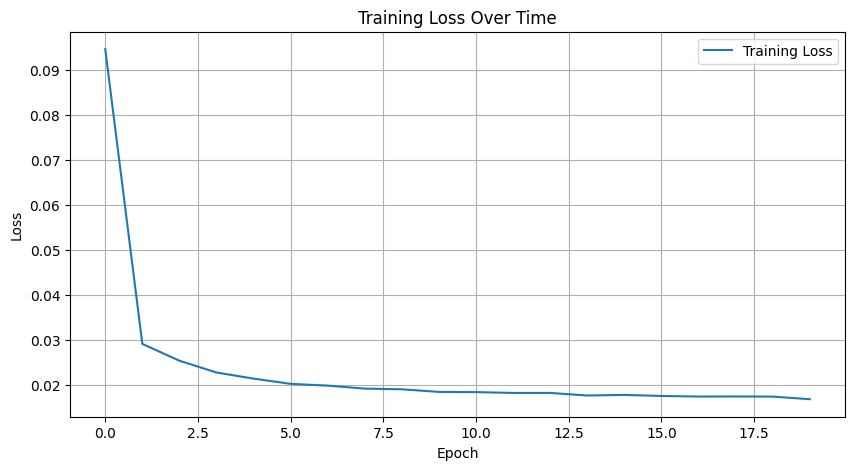

In [56]:
# Lists to store metrics
train_losses = []

# Training loop with visualization
print(f"Training on {DEVICE}")

for epoch in range(EPOCHS):
    # Train for one epoch
    avg_loss = train_epoch(model, train_loader, optimizer, ddpm_sched, NUM_TIMESTEPS, P_UNCOND)
    train_losses.append(avg_loss)
    
    # Print progress
    print(f"Epoch {epoch+1}/{EPOCHS} - Average Loss: {avg_loss:.4f}")
    
    # Generate samples every 10 epochs
    if (epoch + 1) % 10 == 0:
        print(f"\nGenerating samples after epoch {epoch+1}")
        model.eval()
        with torch.no_grad():
            # Generate samples for each digit
            samples_per_digit = 4
            all_samples = []
            
            for digit in range(10):
                # Create condition tensor for this digit
                c = torch.full((samples_per_digit,), digit, device=DEVICE)
                
                # Generate samples
                samples = ddpm_sample(
                    model,
                    ddpm_sched,
                    c,
                    img_wh=(28, 28),
                    num_ts=NUM_TIMESTEPS,
                    guidance_scale=GUIDANCE_SCALE,
                    seed=epoch
                )
                all_samples.append(samples)
            
            # Concatenate all samples
            all_samples = torch.cat(all_samples, dim=0)
            
            # Visualize samples
            plt.figure(figsize=(15, 6))
            for i in range(40):  # Show 4 samples for each digit
                plt.subplot(10, 4, i+1)
                plt.imshow(all_samples[i, 0].cpu(), cmap='gray')
                plt.axis('off')
                if i % 4 == 0:
                    plt.title(f'Digit {i//4}')
            plt.tight_layout()
            plt.show()

# Plot final loss curve
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Over Time')
plt.legend()
plt.grid(True)
plt.show()


In [57]:
# Save the model
torch.save(model.state_dict(), 'class_conditional_unet.pth')
print("Model saved as class_conditional_unet.pth")

Model saved as class_conditional_unet.pth



Generating final samples


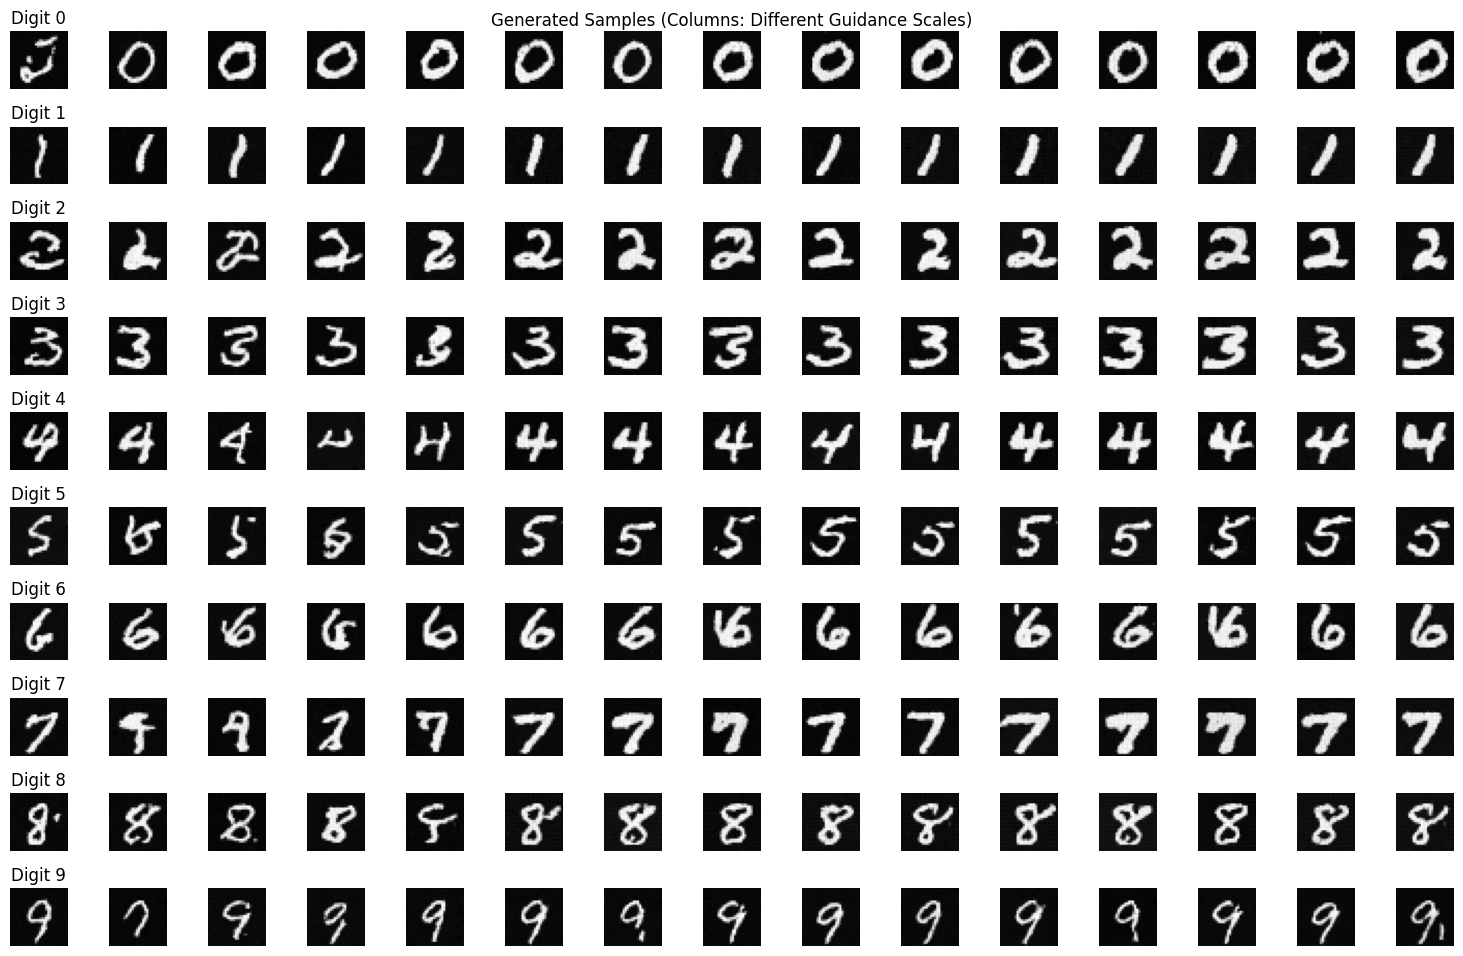

In [58]:
# Generate final test samples
print("\nGenerating final samples")
model.eval()
with torch.no_grad():
    # Generate multiple samples for each digit
    samples_per_digit = 5
    all_samples = []
    
    for digit in range(10):
        # Create condition tensor for this digit
        c = torch.full((samples_per_digit,), digit, device=DEVICE)
        
        # Generate samples with different guidance scales
        for scale in [1.0, 3.0, 5.0]:
            samples = ddpm_sample(
                model,
                ddpm_sched,
                c,
                img_wh=(28, 28),
                num_ts=NUM_TIMESTEPS,
                guidance_scale=scale,
                seed=digit
            )
            all_samples.append(samples)
    
    # Concatenate all samples
    all_samples = torch.cat(all_samples, dim=0)
    
    # Create a grid of samples
    plt.figure(figsize=(15, 10))
    for i in range(len(all_samples)):
        plt.subplot(10, 15, i+1)
        plt.imshow(all_samples[i, 0].cpu(), cmap='gray')
        plt.axis('off')
        if i % 15 == 0:
            plt.title(f'Digit {i//15}', y=1.0)
    plt.suptitle('Generated Samples (Columns: Different Guidance Scales)', y=0.95)
    plt.tight_layout()
    plt.show()



Generating samples for specific digits:


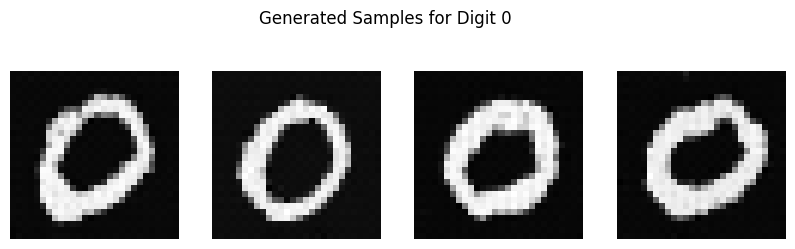

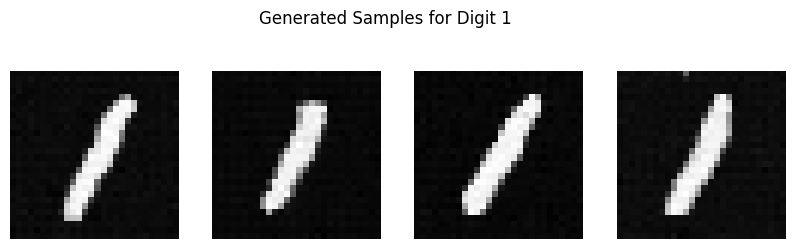

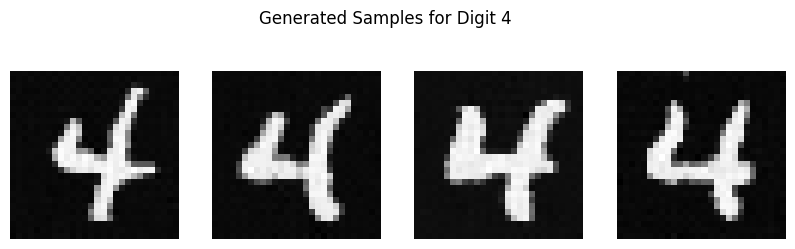

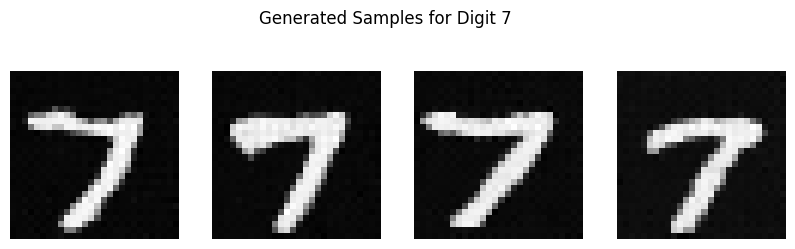

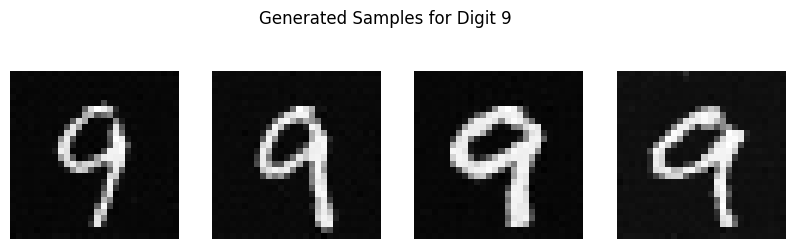

In [60]:
# Function to generate samples for a specific digit
def generate_digit_samples(model, digit, num_samples=4, guidance_scale=3.0):
    model.eval()
    with torch.no_grad():
        c = torch.full((num_samples,), digit, device=DEVICE)
        samples = ddpm_sample(
            model,
            ddpm_sched,
            c,
            img_wh=(28, 28),
            num_ts=NUM_TIMESTEPS,
            guidance_scale=guidance_scale
        )
        
        plt.figure(figsize=(10, 3))
        for i in range(num_samples):
            plt.subplot(1, num_samples, i+1)
            plt.imshow(samples[i, 0].cpu(), cmap='gray')
            plt.axis('off')
        plt.suptitle(f'Generated Samples for Digit {digit}')
        plt.show()

# Example usage:
print("\nGenerating samples for specific digits:")
for digit in [0, 1, 4, 7, 9]:
    generate_digit_samples(model, digit)
